# Adversarial filtering with DUAL discriminator

**The idea:** we take the output of our classifiers, feed it into the generator, and filter for even better tweets.

using **ensemble rejection sampling with our two strongest classifiers**:

1. Take the LLM-generated fakes.
2. Score each one with **BiLSTM** AND with **DistilBERT** —> our two strongest detectors.
3. Keep only the fakes that fooled **BOTH** classifiers (i.e., both predicted "real").
4. Save them as `fake_tweets_adversarial.json`.

**Why two filters instead of one?** A single classifier might have blind spots. Demanding that survivors fool BOTH a strongly different architecture (LSTM) AND a pretrained Transformer (DistilBERT) guarantees the surviving fakes are genuinely hard, not just lucky against one model. This is the standard ensemble approach in adversarial training.

We filter through an ensemble of two architecturally different strong detectors (a bidirectional LSTM trained from scratch and a fine-tuned DistilBERT). Survivors must fool both. This is more rigorous than single-classifier filtering.


## Step 1 — Setup

Required files in Colab directory:
- `data_loader.py`, `tokenizer_util.py`, `06_compare_results.py`
- `tweets.csv`, `fake_tweets_llm.json`
- BiLSTM: `model_03_lstm.pt` + `tokenizer_03.json`
- DistilBERT: `model_05_distilbert/` folder


In [1]:
!pip install torch transformers scikit-learn pandas matplotlib --quiet

In [ ]:
import os
import shutil

# Create the folder
os.makedirs("model_05_distilbert", exist_ok=True)

# Move all DistilBERT-related files into it
distilbert_files = [
    "config.json",
    "model.safetensors",
    "tokenizer.json",
    "tokenizer_config.json",
]

moved = []
for f in distilbert_files:
    if os.path.exists(f):
        shutil.move(f, f"model_05_distilbert/{f}")
        moved.append(f)

print(f"Moved {len(moved)} files into model_05_distilbert/")
print("Contents:", os.listdir("model_05_distilbert"))

Moved 4 files into model_05_distilbert/
Contents: ['model.safetensors', 'config.json', 'tokenizer_config.json', 'tokenizer.json']


In [3]:
import os
needed = [
    "data_loader.py", "tokenizer_util.py", "06_compare_results.py",
    "tweets.csv", "fake_tweets_llm.json",
    "model_03_lstm.pt", "tokenizer_03.json",
]
for f in needed:
    print(f"{'✓' if os.path.exists(f) else '✗'}  {f}")
print(f"{'✓' if os.path.isdir('model_05_distilbert') else '✗'}  model_05_distilbert/")

✓  data_loader.py
✓  tokenizer_util.py
✓  06_compare_results.py
✓  tweets.csv
✓  fake_tweets_llm.json
✓  model_03_lstm.pt
✓  tokenizer_03.json
✓  model_05_distilbert/


## Step 2 — Load the LLM fakes

In [4]:
import json

with open("fake_tweets_llm.json", "r", encoding="utf-8") as f:
    llm_fakes = json.load(f)

print(f"Loaded {len(llm_fakes)} LLM-generated fakes (Llama 3.3 via Groq).")
print("\nFirst 3 examples:")
for t in llm_fakes[:3]:
    print(" -", t)

Loaded 5000 LLM-generated fakes (Llama 3.3 via Groq).

First 3 examples:
 - """@MauriceeTolle: @realDonaldTrump I hope we find the answer that will save you money and your lives."""
 - """@HollyAammer: @realDonaldTrump you are a real patriot. You'll never give up on @realDonaldTrump"""
 - """@RandiKevac: @realDonaldTrump @MittRomney's campaign is pathetic! @GOP #CJ"


## Step 3 — Load BOTH strong classifiers

We load the BiLSTM and the fine-tuned DistilBERT. Each will score every fake independently.

In [5]:
import torch
import importlib.util
import sys

sys.path.insert(0, ".")
from tokenizer_util import Tokenizer, PAD_IDX

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------- Load BiLSTM via the model builder from 06_compare_results.py ----------
spec = importlib.util.spec_from_file_location("compare_mod", "06_compare_results.py")
compare_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(compare_mod)

bilstm_ckpt = torch.load("model_03_lstm.pt", map_location=DEVICE, weights_only=False)
bilstm_tok  = Tokenizer.load("tokenizer_03.json")
bilstm = compare_mod._build_lstm(bilstm_ckpt["config"], bilstm_tok.vocab_len).to(DEVICE)
bilstm.load_state_dict(bilstm_ckpt["model_state_dict"])
bilstm.eval()
print("✓ BiLSTM loaded.")

# ---------- Load DistilBERT ----------
from transformers import AutoTokenizer, AutoModelForSequenceClassification

bert_tok = AutoTokenizer.from_pretrained("model_05_distilbert")
bert     = AutoModelForSequenceClassification.from_pretrained("model_05_distilbert").to(DEVICE)
bert.eval()
print("✓ DistilBERT loaded.")

Device: cpu
✓ BiLSTM loaded.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✓ DistilBERT loaded.


## Step 4 — Score every fake with BOTH classifiers

For each fake, compute P(real) according to BiLSTM and according to DistilBERT.

- **P(real) close to 1** = the classifier thinks this fake looks real → the fake fooled it
- **P(real) close to 0** = the classifier correctly identified it as fake

In [6]:
import torch.nn.functional as F

BATCH_SIZE = 32
MAX_LEN_BILSTM = bilstm_ckpt["config"]["max_len"]

# ---------- Score with BiLSTM ----------
bilstm_probs = []
with torch.no_grad():
    for i in range(0, len(llm_fakes), BATCH_SIZE):
        batch = llm_fakes[i:i+BATCH_SIZE]
        ids = torch.tensor(bilstm_tok.encode_batch(batch, MAX_LEN_BILSTM),
                           dtype=torch.long).to(DEVICE)
        lengths = torch.tensor(
            [max(1, (row != PAD_IDX).sum().item()) for row in ids],
            dtype=torch.long).to(DEVICE)
        logits = bilstm(ids, lengths)
        probs = torch.sigmoid(logits).cpu().numpy()
        bilstm_probs.extend(probs.tolist())

print(f"BiLSTM scored {len(bilstm_probs)} fakes.")
print(f"  Mean P(real) = {sum(bilstm_probs)/len(bilstm_probs):.3f}")

# ---------- Score with DistilBERT ----------
bert_probs = []
with torch.no_grad():
    for i in range(0, len(llm_fakes), BATCH_SIZE):
        batch = llm_fakes[i:i+BATCH_SIZE]
        enc = bert_tok(batch, truncation=True, padding=True,
                       max_length=64, return_tensors="pt").to(DEVICE)
        logits = bert(**enc).logits
        # Label 1 = "real"
        probs = F.softmax(logits, dim=-1)[:, 1].cpu().numpy()
        bert_probs.extend(probs.tolist())

print(f"DistilBERT scored {len(bert_probs)} fakes.")
print(f"  Mean P(real) = {sum(bert_probs)/len(bert_probs):.3f}")

BiLSTM scored 5000 fakes.
  Mean P(real) = 0.805
DistilBERT scored 5000 fakes.
  Mean P(real) = 0.962


## Step 5 — Visualize both scores together

A 2D scatter plot shows where each fake falls on the agreement spectrum:

- **Top-right quadrant:** both classifiers fooled — these are the adversarial survivors
- **Bottom-left quadrant:** both classifiers caught it (easy fakes)
- **Top-left / bottom-right:** disagreement, only one classifier was fooled

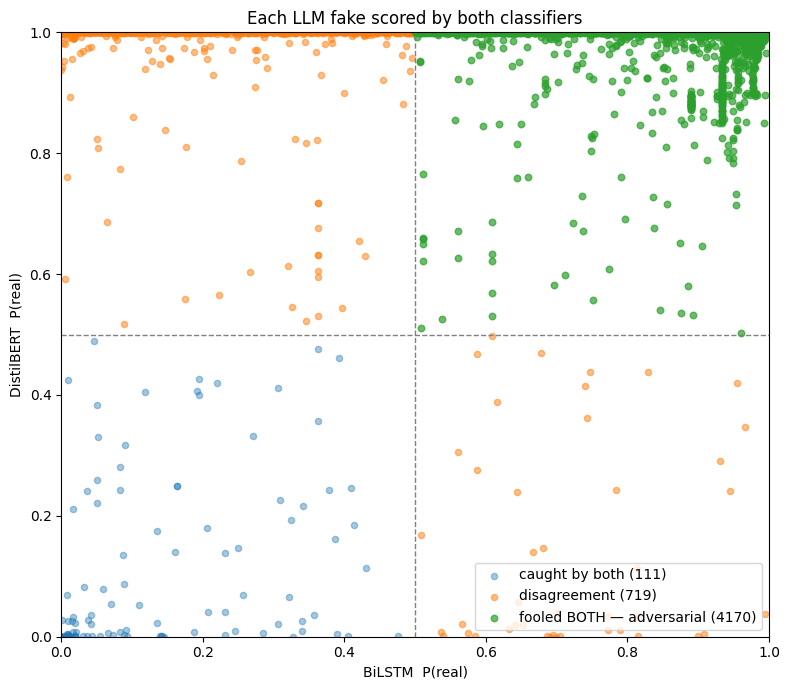

In [7]:
import matplotlib.pyplot as plt
import numpy as np

bilstm_arr = np.array(bilstm_probs)
bert_arr   = np.array(bert_probs)

THRESHOLD = 0.5
fooled_both    = (bilstm_arr >= THRESHOLD) & (bert_arr >= THRESHOLD)
fooled_neither = (bilstm_arr <  THRESHOLD) & (bert_arr <  THRESHOLD)
disagreement   = ~(fooled_both | fooled_neither)

plt.figure(figsize=(8, 7))
plt.scatter(bilstm_arr[fooled_neither], bert_arr[fooled_neither],
            alpha=0.4, s=20, label=f"caught by both ({fooled_neither.sum()})")
plt.scatter(bilstm_arr[disagreement], bert_arr[disagreement],
            alpha=0.5, s=20, label=f"disagreement ({disagreement.sum()})")
plt.scatter(bilstm_arr[fooled_both], bert_arr[fooled_both],
            alpha=0.7, s=22, label=f"fooled BOTH — adversarial ({fooled_both.sum()})")
plt.axhline(THRESHOLD, color="gray", linestyle="--", linewidth=1)
plt.axvline(THRESHOLD, color="gray", linestyle="--", linewidth=1)
plt.xlabel("BiLSTM  P(real)")
plt.ylabel("DistilBERT  P(real)")
plt.title("Each LLM fake scored by both classifiers")
plt.legend(loc="lower right")
plt.xlim(0, 1); plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("dual_filter_scatter.png", dpi=150)
plt.show()

## Step 6 — Filter: keep only fakes that fooled BOTH

We're strict —> survivors must fool BiLSTM AND DistilBERT simultaneously. These are first generated tweets "even better tweets" produced by the LLM and validated to slip past both detectors.

In [8]:
# Pair each fake with both scores
scored = list(zip(llm_fakes, bilstm_probs, bert_probs))

# Intersection filter: both >= 0.5
adversarial = [t for t, b, d in scored if b >= THRESHOLD and d >= THRESHOLD]

# For comparison/analysis, also compute single-filter sets
bilstm_only_survivors = [t for t, b, d in scored if b >= THRESHOLD]
bert_only_survivors   = [t for t, b, d in scored if d >= THRESHOLD]

print(f"Total LLM fakes:                {len(llm_fakes)}")
print(f"Survived BiLSTM alone:          {len(bilstm_only_survivors)}")
print(f"Survived DistilBERT alone:      {len(bert_only_survivors)}")
print(f"Survived BOTH (adversarial):    {len(adversarial)}")
print(f"  → that's our final filtered set")

# Save the main adversarial set (intersection)
with open("fake_tweets_adversarial.json", "w", encoding="utf-8") as f:
    json.dump(adversarial, f, indent=2, ensure_ascii=False)
print("\n✓ Saved fake_tweets_adversarial.json")

# Also save the scores for the slide-deck plotting later
import json as _json
with open("dual_filter_scores.json", "w") as f:
    _json.dump({
        "tweets": llm_fakes,
        "bilstm_probs": bilstm_probs,
        "bert_probs": bert_probs,
    }, f)
print("✓ Saved dual_filter_scores.json (for later analysis)")

Total LLM fakes:                5000
Survived BiLSTM alone:          4213
Survived DistilBERT alone:      4846
Survived BOTH (adversarial):    4170
  → that's our final filtered set

✓ Saved fake_tweets_adversarial.json
✓ Saved dual_filter_scores.json (for later analysis)


## Step 7 — What do the survivors look like vs the caught ones?

The interesting case is sorting by average P(real) —> the highest average fakes fooled both classifiers the most.

In [9]:
# Sort by combined "fooled" score
combined = [(t, b, d, (b+d)/2) for t, b, d in scored]
combined.sort(key=lambda x: x[3])

print("=" * 70)
print("MOST EASILY CAUGHT (both classifiers very confident they're fake):")
print("=" * 70)
for tweet, b, d, _ in combined[:5]:
    print(f"\n  BiLSTM P(real)={b:.3f}   DistilBERT P(real)={d:.3f}")
    print(f"  → {tweet[:200]}")

print("\n" + "=" * 70)
print("STRONGEST ADVERSARIAL FAKES (fooled both classifiers):")
print("=" * 70)
for tweet, b, d, _ in combined[-5:]:
    print(f"\n  BiLSTM P(real)={b:.3f}   DistilBERT P(real)={d:.3f}")
    print(f"  → {tweet[:200]}")

MOST EASILY CAUGHT (both classifiers very confident they're fake):

  BiLSTM P(real)=0.000   DistilBERT P(real)=0.000
  → """@TheDailyBeast @BarackObama

  BiLSTM P(real)=0.000   DistilBERT P(real)=0.000
  → """@Lilitha4ThePump                        @foxandfriends

  BiLSTM P(real)=0.001   DistilBERT P(real)=0.000
  → """@donta_chuck

  BiLSTM P(real)=0.001   DistilBERT P(real)=0.000
  → """@dickcadillac_china

  BiLSTM P(real)=0.001   DistilBERT P(real)=0.000
  → """@_joe_shifty

STRONGEST ADVERSARIAL FAKES (fooled both classifiers):

  BiLSTM P(real)=1.000   DistilBERT P(real)=1.000
  → The Obama Administration should not pay a penny for the faulty poll. The Dems &amp, Dems are already making millions from the fake Polling which will never give them any votes!

  BiLSTM P(real)=1.000   DistilBERT P(real)=1.000
  → The New York Times is so pathetic &amp; wrong that it is completely out-of-touch with their true story. I'm calling them a 'trusted source.'

  BiLSTM P(real)=1.000   Dist

## Step 8 — Summary

Now we have:
- `fake_tweets_adversarial.json` —> the ensemble-filtered fakes (fooled both BiLSTM and DistilBERT)
- `dual_filter_scatter.png` —> visualization for the slides
- `dual_filter_scores.json` —> raw scores in case you want to make custom plots


1. We applied an adversarial feedback loop using TWO architecturally different strong detectors
2. Survivors are by construction the LLM fakes that fool both an LSTM (sequence-based) AND a pretrained Transformer (semantic-based)
3. This is the kind of "smart fakes" the next round of classifiers will struggle most against

**Next step:** to test all 5 classifiers against these survivors.
